In [1]:
!pip install ucimlrepo

In [76]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from joblib import dump

## Loading Data

In [3]:
hcv = fetch_ucirepo(id=571)

In [4]:
hcv.data

{'ids':       ID
 0      1
 1      2
 2      3
 3      4
 4      5
 ..   ...
 610  611
 611  612
 612  613
 613  614
 614  615
 
 [615 rows x 1 columns],
 'features':      Age Sex   ALB    ALP    AST   BIL    CHE  CHOL   CREA    CGT  PROT    ALT
 0     32   m  38.5   52.5   22.1   7.5   6.93  3.23  106.0   12.1  69.0    7.7
 1     32   m  38.5   70.3   24.7   3.9  11.17  4.80   74.0   15.6  76.5   18.0
 2     32   m  46.9   74.7   52.6   6.1   8.84  5.20   86.0   33.2  79.3   36.2
 3     32   m  43.2   52.0   22.6  18.9   7.33  4.74   80.0   33.8  75.7   30.6
 4     32   m  39.2   74.1   24.8   9.6   9.15  4.32   76.0   29.9  68.7   32.6
 ..   ...  ..   ...    ...    ...   ...    ...   ...    ...    ...   ...    ...
 610   62   f  32.0  416.6  110.3  50.0   5.57  6.30   55.7  650.9  68.5    5.9
 611   64   f  24.0  102.8   44.4  20.0   1.54  3.02   63.0   35.9  71.3    2.9
 612   64   f  29.0   87.3   99.0  48.0   1.66  3.63   66.7   64.2  82.0    3.5
 613   46   f  33.0    NaN   62.0 

In [5]:
X = hcv.data.features
X

,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6
...,...,...,...,...,...,...,...,...,...,...,...,...
610,62,f,32.0,416.6,110.3,50.0,5.57,6.30,55.7,650.9,68.5,5.9
611,64,f,24.0,102.8,44.4,20.0,1.54,3.02,63.0,35.9,71.3,2.9
612,64,f,29.0,87.3,99.0,48.0,1.66,3.63,66.7,64.2,82.0,3.5
613,46,f,33.0,NaN,62.0,20.0,3.56,4.20,52.0,50.0,71.0,39.0


In [6]:
y = hcv.data.targets
y

,Category
0,0=Blood Donor
1,0=Blood Donor
2,0=Blood Donor
3,0=Blood Donor
4,0=Blood Donor
...,...
610,3=Cirrhosis
611,3=Cirrhosis
612,3=Cirrhosis
613,3=Cirrhosis


In [7]:
y.value_counts()

Category              
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64

In [8]:
X.shape

(615, 12)

In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     615 non-null    int64  
 1   Sex     615 non-null    object 
 2   ALB     614 non-null    float64
 3   ALP     597 non-null    float64
 4   AST     615 non-null    float64
 5   BIL     615 non-null    float64
 6   CHE     615 non-null    float64
 7   CHOL    605 non-null    float64
 8   CREA    615 non-null    float64
 9   CGT     615 non-null    float64
 10  PROT    614 non-null    float64
 11  ALT     614 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 57.8+ KB


In [10]:
X.isna().sum()

Age      0
Sex      0
ALB      1
ALP     18
AST      0
BIL      0
CHE      0
CHOL    10
CREA     0
CGT      0
PROT     1
ALT      1
dtype: int64

In [11]:
df = pd.concat([X,y],axis=1)
df.head()

,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT,Category
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7,0=Blood Donor
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0,0=Blood Donor
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2,0=Blood Donor
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6,0=Blood Donor
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6,0=Blood Donor


In [12]:
target_column = y.columns[0]
target_column

'Category'

In [13]:
df['disease'] = (~df[target_column].astype(str).str.lower().str.contains('blood donor')).astype(int)
df.head()

,Age,Sex,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT,Category,disease
0,32,m,38.5,52.5,22.1,7.5,6.93,3.23,106.0,12.1,69.0,7.7,0=Blood Donor,0
1,32,m,38.5,70.3,24.7,3.9,11.17,4.80,74.0,15.6,76.5,18.0,0=Blood Donor,0
2,32,m,46.9,74.7,52.6,6.1,8.84,5.20,86.0,33.2,79.3,36.2,0=Blood Donor,0
3,32,m,43.2,52.0,22.6,18.9,7.33,4.74,80.0,33.8,75.7,30.6,0=Blood Donor,0
4,32,m,39.2,74.1,24.8,9.6,9.15,4.32,76.0,29.9,68.7,32.6,0=Blood Donor,0


In [14]:
df.groupby(target_column)['disease'].value_counts()

Category                disease
0=Blood Donor           0          533
0s=suspect Blood Donor  0            7
1=Hepatitis             1           24
2=Fibrosis              1           21
3=Cirrhosis             1           30
Name: count, dtype: int64

In [15]:
df.isna().sum()

Age          0
Sex          0
ALB          1
ALP         18
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
CGT          0
PROT         1
ALT          1
Category     0
disease      0
dtype: int64

In [16]:
df.describe()

,Age,ALB,ALP,AST,BIL,CHE,CHOL,CREA,CGT,PROT,ALT,disease
count,615.000000,614.000000,597.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000,614.000000,614.000000,615.000000
mean,47.408130,41.620195,68.283920,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171,72.044137,28.450814,0.121951
std,10.055105,5.780629,26.028315,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071,5.402636,25.469689,0.327496
min,19.000000,14.900000,11.300000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000,0.900000,0.000000
25%,39.000000,38.800000,52.500000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000,69.300000,16.400000,0.000000
50%,47.000000,41.950000,66.200000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000,23.000000,0.000000
75%,54.000000,45.200000,80.100000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000,75.400000,33.075000,0.000000
max,77.000000,82.200000,416.600000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000,325.300000,1.000000


# EDA

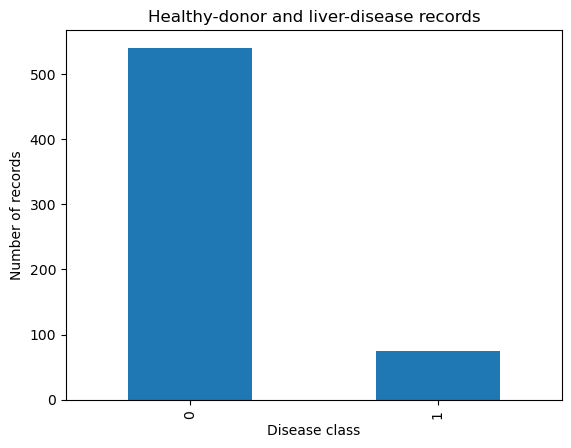

In [17]:
df['disease'].value_counts().plot(kind='bar')
plt.title("Healthy-donor and liver-disease records")
plt.xlabel("Disease class")
plt.ylabel("Number of records")
plt.savefig('Healthy-donor and liver-disease records.png',dpi=200,bbox_inches='tight')

<Figure size 3000x1600 with 0 Axes>

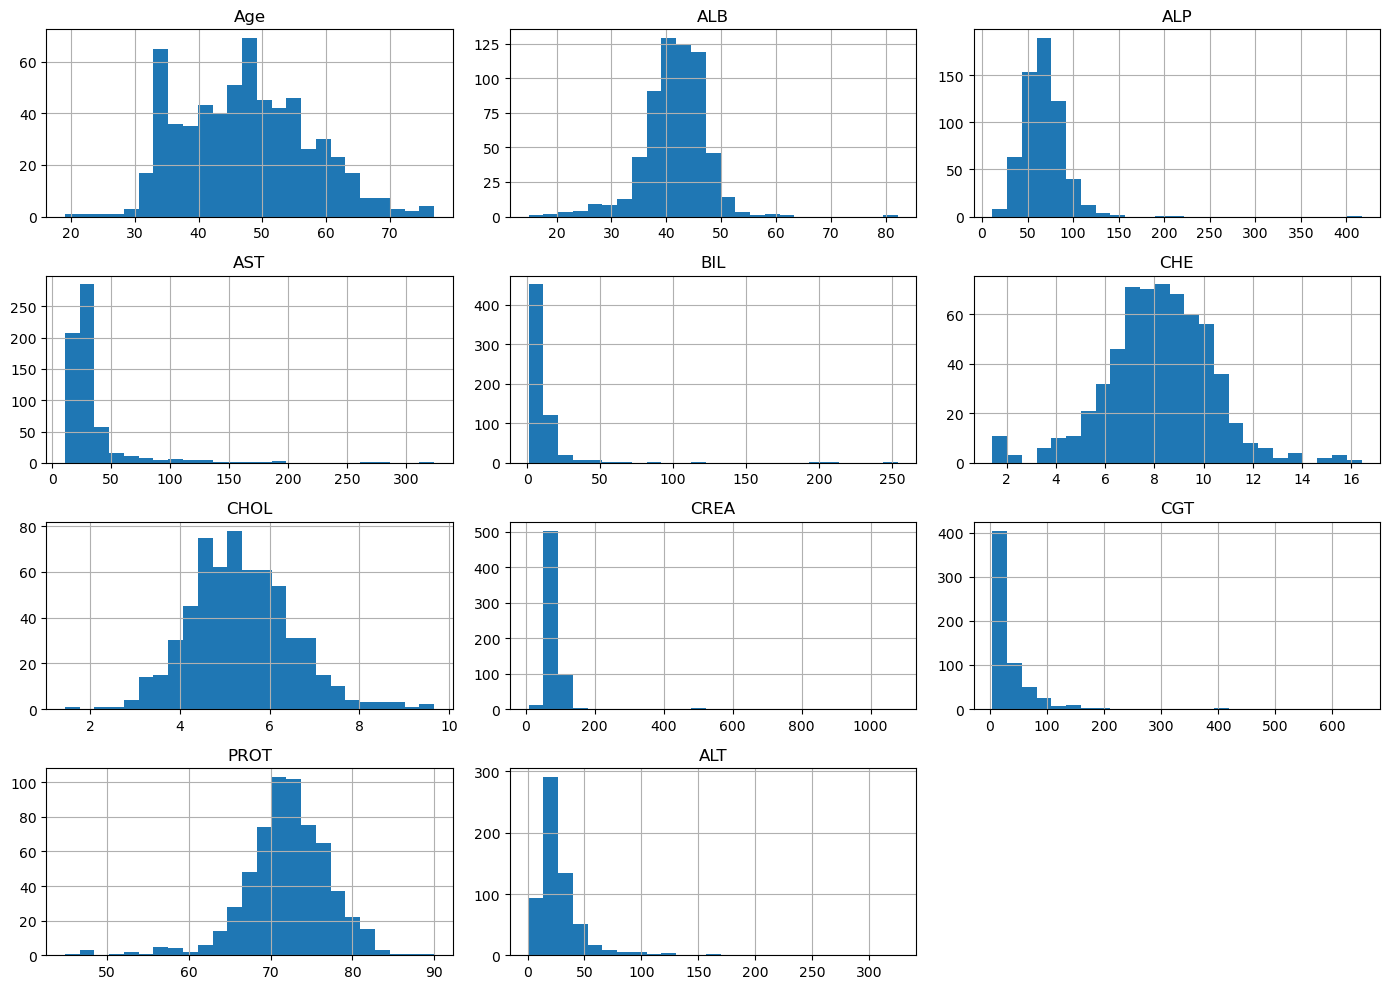

In [18]:
plt.figure(figsize=(15,8),dpi=200)
numeric_columns = X.select_dtypes(include="number").columns
df[numeric_columns].hist(figsize=(14, 10), bins=25)
plt.tight_layout()
plt.savefig('Distributions of numeric columns.png',bbox_inches='tight')

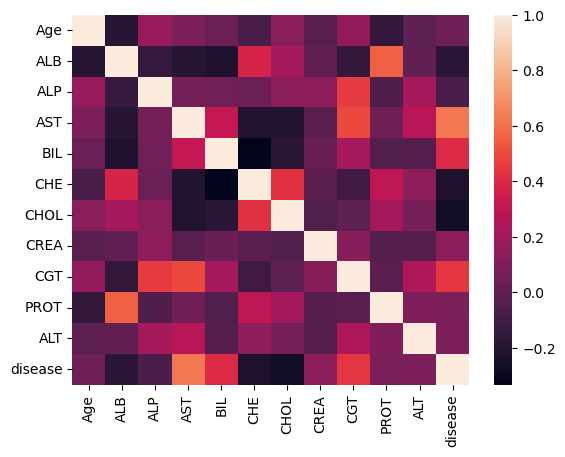

In [19]:
sns.heatmap(df.corr(numeric_only=True))
plt.savefig('Heatmap.png',dpi=200,bbox_inches='tight')

In [20]:
df.corr(numeric_only=True)['disease'].sort_values().drop('disease')

CHOL   -0.270496
CHE    -0.230785
ALB    -0.180923
ALP    -0.069342
Age     0.037781
PROT    0.084453
ALT     0.089251
CREA    0.136772
BIL     0.398451
CGT     0.437680
AST     0.621724
Name: disease, dtype: float64

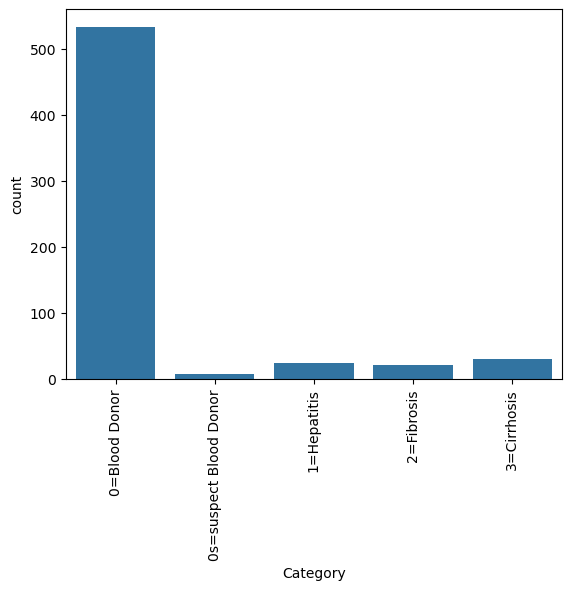

In [21]:
sns.countplot(data=df,x='Category')
plt.xticks(rotation=90);

<Axes: xlabel='disease', ylabel='Age'>

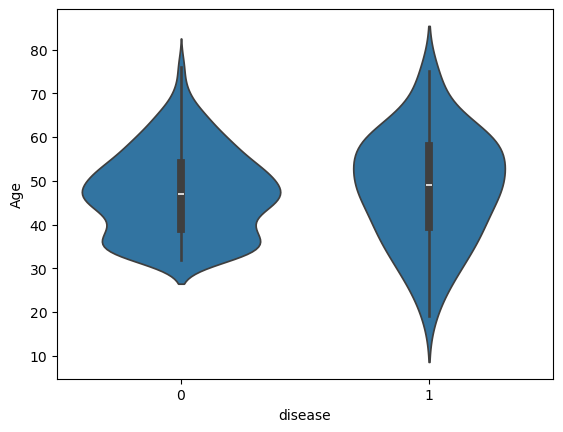

In [22]:
sns.violinplot(data=df,x='disease',y='Age')

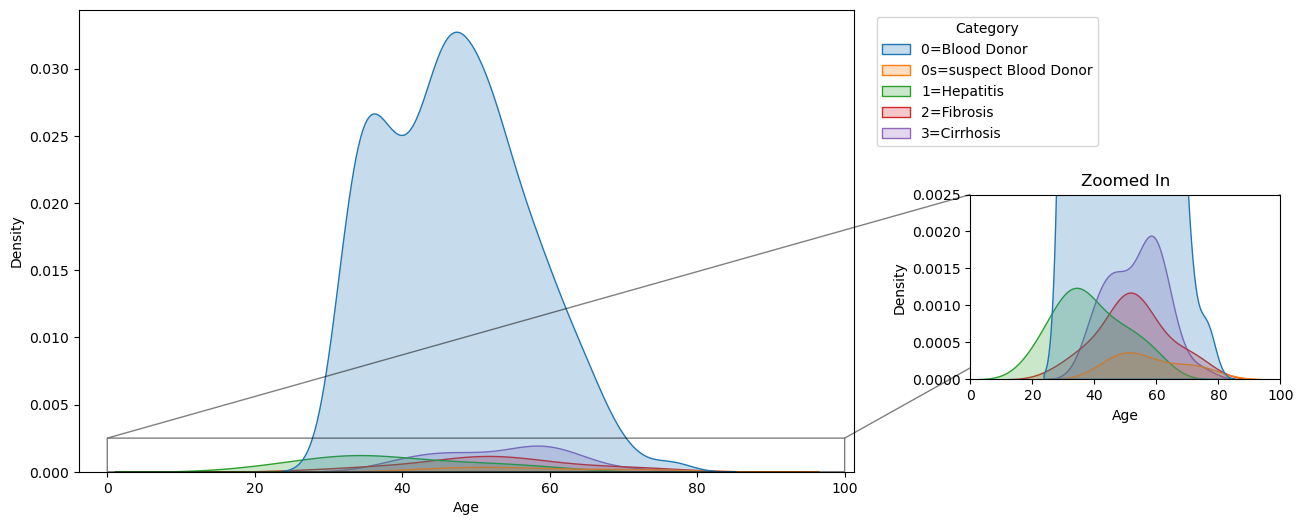

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.kdeplot(data=df, x='Age', hue='Category', fill=True, ax=ax)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))
ax_zoom = ax.inset_axes([1.15, 0.2, 0.4, 0.4])
sns.kdeplot(data=df, x='Age', hue='Category', fill=True, ax=ax_zoom, legend=False)
ax_zoom.set_ylim(0, 0.0025)
ax_zoom.set_xlim(0, 100)
ax_zoom.set_title('Zoomed In')
ax.indicate_inset_zoom(ax_zoom, edgecolor="black")

plt.savefig('Age Distribution.png',dpi=200,bbox_inches='tight')

<Axes: xlabel='AST', ylabel='ALT'>

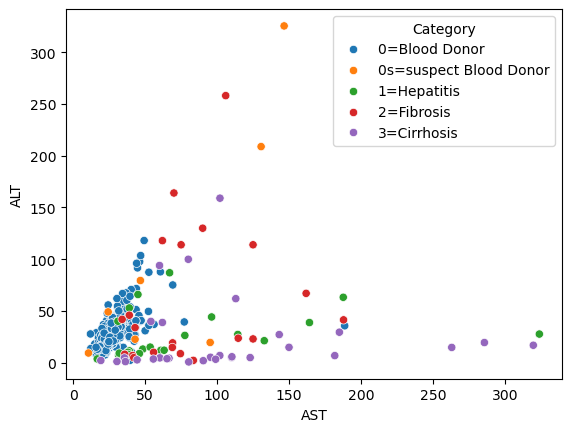

In [24]:
sns.scatterplot(data=df,x='AST',y='ALT',hue='Category')

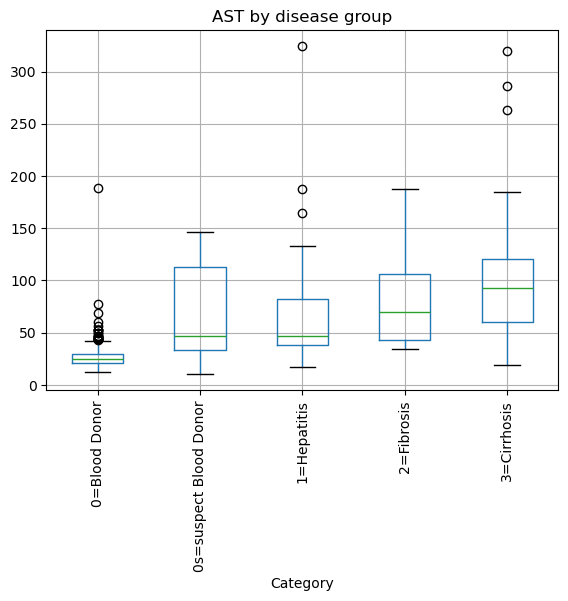

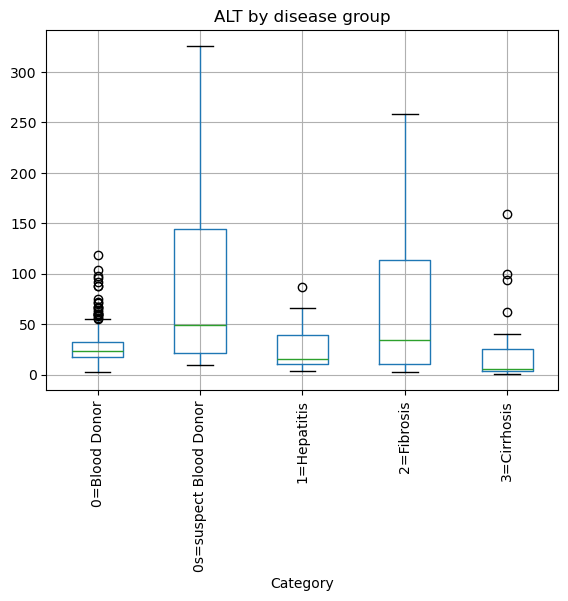

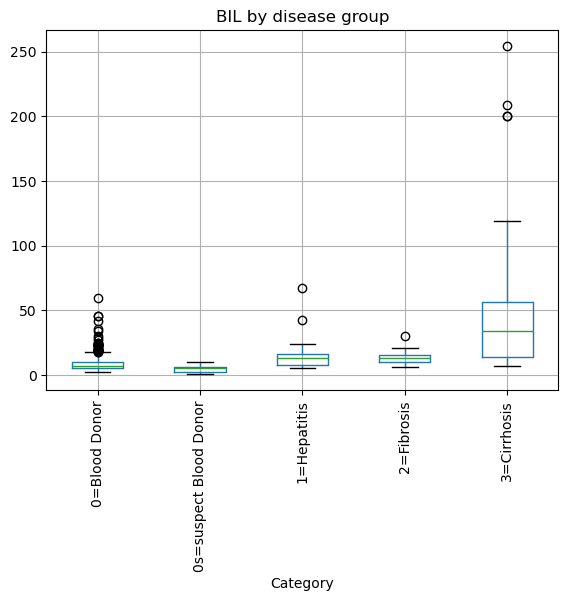

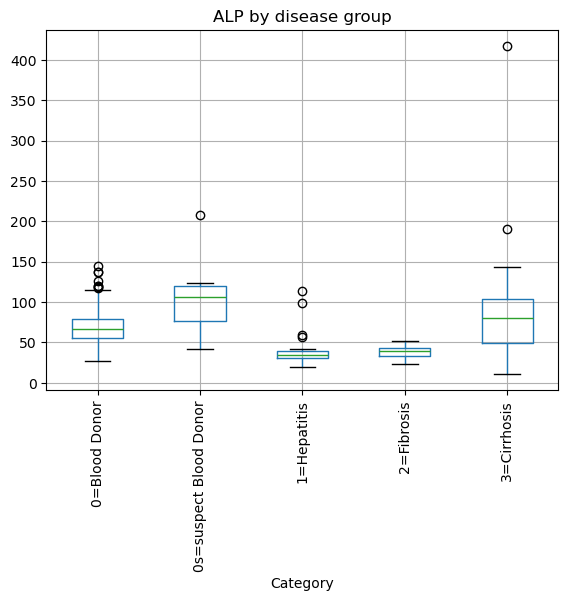

In [25]:
for column in ["AST", "ALT", "BIL", "ALP"]:
    if column in df.columns:
        df.boxplot(column=column, by="Category")
        plt.title(f"{column} by disease group")
        plt.suptitle("")
        plt.xticks(rotation=90)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       615 non-null    int64  
 1   Sex       615 non-null    object 
 2   ALB       614 non-null    float64
 3   ALP       597 non-null    float64
 4   AST       615 non-null    float64
 5   BIL       615 non-null    float64
 6   CHE       615 non-null    float64
 7   CHOL      605 non-null    float64
 8   CREA      615 non-null    float64
 9   CGT       615 non-null    float64
 10  PROT      614 non-null    float64
 11  ALT       614 non-null    float64
 12  Category  615 non-null    object 
 13  disease   615 non-null    int64  
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


## Supervised Learning

In [27]:
X_model = hcv.data.features.copy()
category = hcv.data.targets["Category"].astype(str)
y_model = (
    ~category.str.lower().str.contains("blood donor")
).astype(int)

print("Target distribution:")
print(y_model.value_counts())

Target distribution:
Category
0    540
1     75
Name: count, dtype: int64


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.1,
    stratify=y_model,
    random_state=42
)

In [29]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

In [30]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [31]:
pipelines = {
    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier())
    ]),
    
    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("model", SVC(probability=True, class_weight="balanced", random_state=42))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(bootstrap=True, class_weight="balanced", random_state=42))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

In [32]:
param_grids = {
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15]
    },
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"]
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 4, 5, None],
        "model__min_samples_leaf": [1, 2, 3],
        "model__oob_score":[True,False]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.1, 0.2],
        "model__max_depth": [3, 4, 5]
    }
}

Training KNN 
Best Parameters: {'model__n_neighbors': 11}
Confusion Matrix:


Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95        54
           1       0.75      0.38      0.50         8

    accuracy                           0.90        62
   macro avg       0.83      0.68      0.72        62
weighted avg       0.89      0.90      0.89        62

ROC-AUC Score: 0.9097


Training SVM 
Best Parameters: {'model__C': 1, 'model__kernel': 'rbf'}
Confusion Matrix:


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95        54
           1       0.71      0.62      0.67         8

    accuracy                           0.92        62
   macro avg       0.83      0.79      0.81        62
weighted avg       0.92      0.92      0.92        62

ROC-AUC Score: 0.9699


Training Random Forest 
Best Parameters: {'model__max_depth': None, 'model__min_s

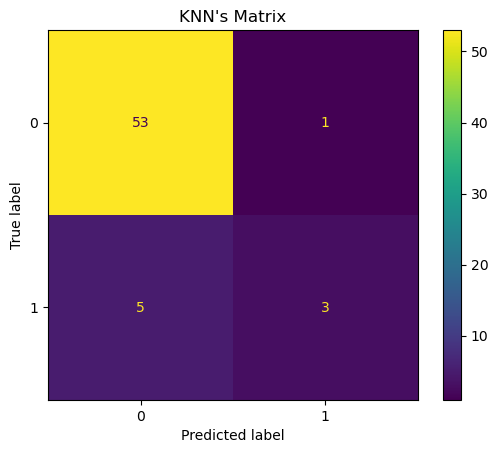

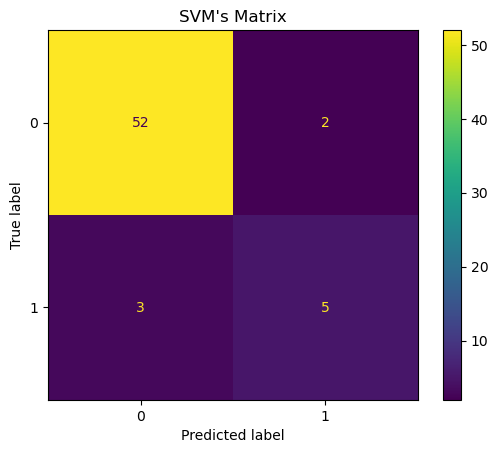

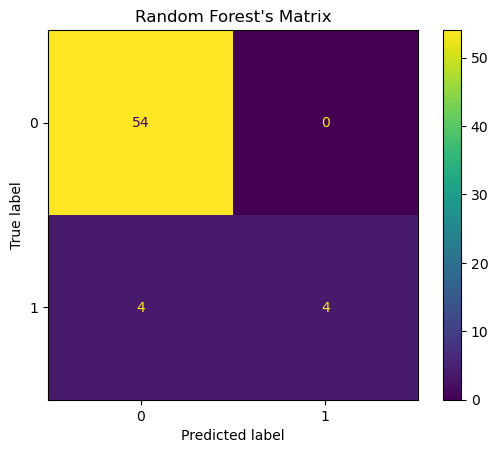

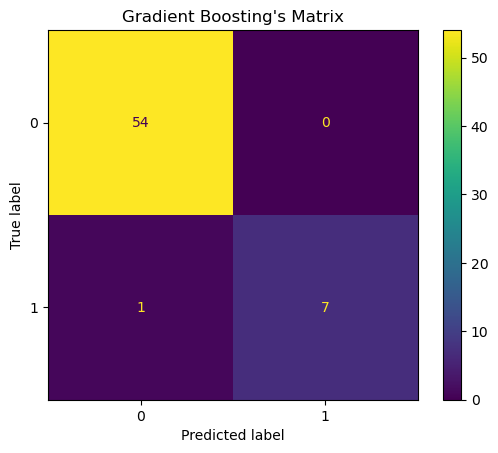

In [88]:
for name, pipeline in pipelines.items():
    print(f"Training {name} ")

    inner_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=inner_cv, 
        scoring='roc_auc', 
        n_jobs=-1 
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    
    predictions = best_model.predict(X_test)
    probabilities = best_model.predict_proba(X_test)[:, 1]
    
    print(f"Best Parameters: {grid_search.best_params_}")
    print("Confusion Matrix:\n")
    ConfusionMatrixDisplay.from_predictions(y_test, predictions);
    plt.title(f'{name}\'s Matrix')
    plt.savefig(f'{name}\'s Confusion Matrix.png',dpi=200,bbox_inches='tight')
    print("\nClassification Report:\n", classification_report(y_test, predictions))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, probabilities):.4f}\n\n")

    dump(best_model,f'{name} model.joblib')

## Unsupervised Learning

In [38]:
X_numeric = X_model.select_dtypes(include="number")

In [39]:
X_imputed = SimpleImputer(
    strategy="median"
).fit_transform(X_numeric)

In [40]:
X_scaled = StandardScaler().fit_transform(X_imputed)

In [81]:
pca = PCA(n_components=2)

In [82]:
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-0.41732582, -2.13818374],
       [ 1.12330324, -0.21210838],
       [ 1.04463491,  0.78877556],
       ...,
       [-3.92559767, -0.39715275],
       [-2.36633117, -0.8854228 ],
       [-1.34573727,  1.3352631 ]], shape=(615, 2))

In [83]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Disease": y_model.to_numpy()
})
pca_df

,PC1,PC2,Disease
0,-0.417326,-2.138184,0
1,1.123303,-0.212108,0
2,1.044635,0.788776,0
3,0.439124,-0.593569,0
4,-0.040510,-0.620659,0
...,...,...,...
610,-9.290792,10.633237,1
611,-3.946652,-1.833670,1
612,-3.925598,-0.397153,1
613,-2.366331,-0.885423,1


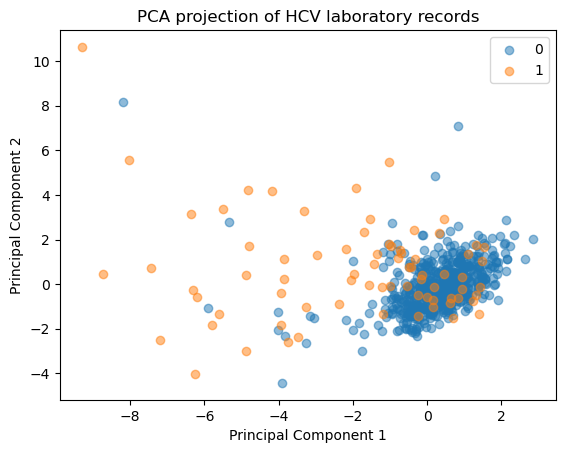

In [84]:
for disease_class in sorted(pca_df["Disease"].unique()):
    subset = pca_df[pca_df["Disease"] == disease_class]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=str(disease_class),
        alpha=0.5
    )

    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.title("PCA projection of HCV laboratory records")
    plt.legend()
    plt.savefig(f"Principle Component.png",dpi=200,bbox_inches='tight')

In [85]:
pca.explained_variance_ratio_

array([0.22379276, 0.16524339])

In [86]:
print("Total Variance percentage explained by 2 Principal Components:")
pca.explained_variance_ratio_.sum()

Total Variance percentage explained by 2 Principal Components:


np.float64(0.3890361591275746)

In [87]:
dump(pca,'2 components PCA model.joblib')

['2 components PCA model.joblib']

In [56]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [57]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "PC3": X_pca[:, 2], 
    "Disease": y_model.to_numpy()
})

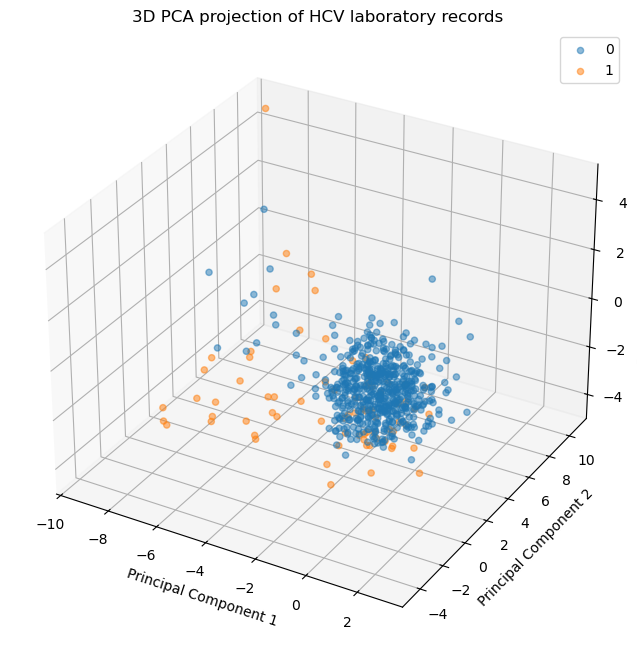

In [70]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for disease_class in sorted(pca_df["Disease"].unique()):
    subset = pca_df[pca_df["Disease"] == disease_class]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"], 
        label=str(disease_class),
        alpha=0.5
    )

    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.set_zlabel("Principal Component 3")
    ax.set_title("3D PCA projection of HCV laboratory records")
    ax.legend()

    plt.savefig('3D PCA Projection.png',dpi=200,bbox_inches='tight')

In [74]:
pca.explained_variance_ratio_

array([0.22379276, 0.16524339, 0.12418586])

In [79]:
print("Total Variance percentage explained by 3 Principal Components:")
pca.explained_variance_ratio_.sum()

Total Variance percentage explained by 3 Principal Components:


np.float64(0.5132220171716534)

In [80]:
dump(pca,'3 Component PCA model.joblib')

['3 Component PCA model.joblib']

In [65]:
for k in [2, 3, 4]:
    kmeans = KMeans(n_clusters=k,random_state=42)

    cluster_labels = kmeans.fit_predict(X_scaled)

    print("Clusters: ",k)
    print("Silhouette score: ",silhouette_score(X_scaled, cluster_labels))


Clusters:  2
Silhouette score:  0.5941817970720287
Clusters:  3
Silhouette score:  0.134431491646789
Clusters:  4
Silhouette score:  0.12596370779780822


C:\Users\ycnit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\ycnit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\ycnit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [77]:
kmeans = KMeans(n_clusters=2,random_state=42)
pca_df["Cluster"] = kmeans.fit_predict(X_scaled)
print(pd.crosstab(
        pca_df["Cluster"],
        pca_df["Disease"],
        normalize="index"
    ))

Disease         0         1
Cluster                    
0        0.915371  0.084629
1        0.277778  0.722222


C:\Users\ycnit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [78]:
dump(kmeans,'KMeans model.joblib')

['KMeans model.joblib']